<a href="https://colab.research.google.com/github/HanAbdulaziz/-learning-git/blob/main/Lab3.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Geometric & Intensity Transformations


Apply classical image processing operations using Python and the `(PIL)` library. Complete both tasks and save your output images for comparison.


In [26]:
# Import the library
from PIL import Image, ImageOps
import numpy as np
import matplotlib.pyplot as plt


In [27]:
# ── Load image ────────────────────────────────────
from google.colab import files
uploaded = files.upload()


Saving IMG_0822.jpeg to IMG_0822 (1).jpeg


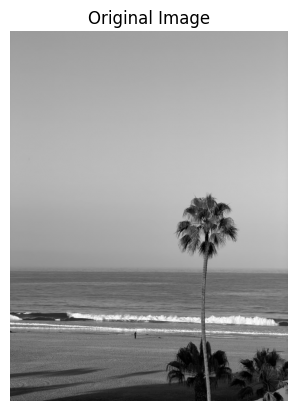

In [28]:
filename = list(uploaded.keys())[0]
img = Image.open(filename).convert('L')

plt.imshow(img, cmap='gray')
plt.title('Original Image')
plt.axis('off')
plt.show()


### 1. Scale (increase size)
Double the image dimensions using `Image.resize()` with high-quality resampling `(LANCZOS)`.

In [29]:
# Get the size of the image
original_size = img.size
print("Original size:", original_size)
# scaling factors
scale_factor = 2
new_size = (original_size[0] * scale_factor, original_size[1] * scale_factor)


Original size: (1200, 1600)


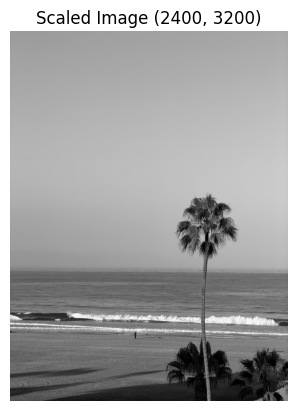

In [30]:
# ── 1. Increase size (scale ×2) ────────────────────

# Resize the image using PIL's built-in method
scaled_img = img.resize(new_size, Image.Resampling.LANCZOS)

plt.imshow(scaled_img, cmap='gray')
plt.title(f'Scaled Image {new_size}')
plt.axis('off')
plt.show()


In [31]:

# Save the scaled image and print the sizes (The new image name should be "task1_1_scaled.jpg")
scaled_img.save('task1_1_scaled.jpg')

print("Original size:", img.size)
print("Scaled size:", scaled_img.size)



Original size: (1200, 1600)
Scaled size: (2400, 3200)


 non-uniform scale (cx=2, cy=1) → stretch horizontally only

In [32]:
cx, cy = 2, 1
non_uniform_size = (original_size[0] * cx, original_size[1] * cy)


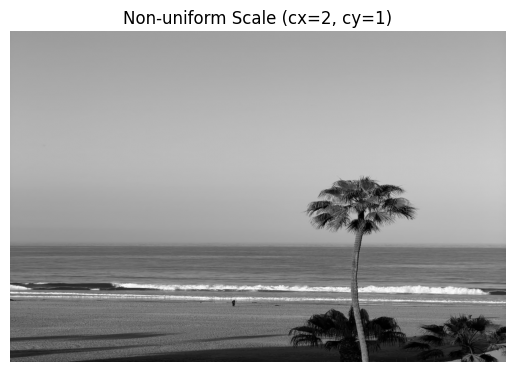

In [33]:
non_uniform_img = img.resize(non_uniform_size, Image.Resampling.LANCZOS)

plt.imshow(non_uniform_img, cmap='gray')
plt.title(f'Non-uniform Scale (cx={cx}, cy={cy})')
plt.axis('off')
plt.show()


In [34]:
non_uniform_img.save('task1_1b_nonuniform.jpg')
print("Original size:", img.size)
print("Non-uniform scaled size:", non_uniform_img.size)


Original size: (1200, 1600)
Non-uniform scaled size: (2400, 1600)


### 2. Rotate 120°
Rotate the image by 120 degrees, expanding the canvas to fit the full rotated image.

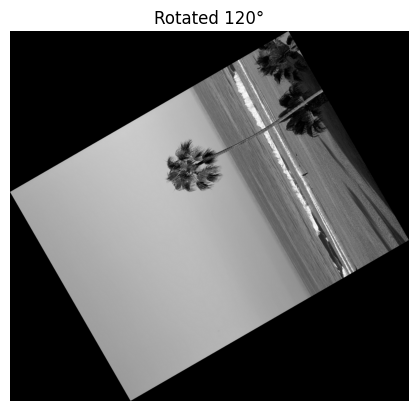

Original size: (1200, 1600)
Rotated size: (1986, 1840)


In [35]:
# ── 2. Rotate 120 degrees ──────────────────────────
rotated_img = img.rotate(120, expand=True, resample=Image.Resampling.BICUBIC)

plt.imshow(rotated_img, cmap='gray')
plt.title('Rotated 120°')
plt.axis('off')
plt.show()

# Save the scaled image and print the sizes (The new image name should be "task1_2_rotated.jpg")
rotated_img.save('task1_2_rotated.jpg')

print("Original size:", img.size)
print("Rotated size:", rotated_img.size)


### 3. Shear

In [36]:
# -- c. Get the image dimensions ────────────────────
width, height = img.size
print("Width:", width, "Height:", height)


Width: 1200 Height: 1600


In [37]:
# -- d. define the shear matrix ──────────────────────────
# Choose X-axis or Y-axis shear. The shear factor controls how much the image slants — start with 0.5 then experiment.
shear_factor = 0.5

# X-axis shear matrix
shear_matrix = (1, shear_factor, 0,
                 0, 1, 0)

# Canvas needs to be wider to fit the sheared image
new_width = width + int(shear_factor * height)
new_height = height


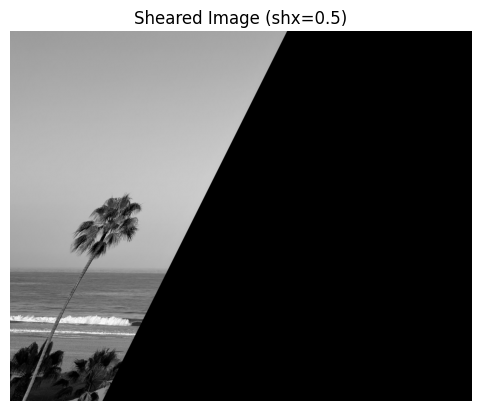

In [38]:
# -- e. Apply the shear transformation to the image ──────────────────────────
# PIL's transform() takes the inverse affine matrix:
# [ 1    shx   tx ]
# [ shy  1     ty ]
sheared_img = img.transform((new_width, new_height), Image.AFFINE, shear_matrix, resample=Image.Resampling.BICUBIC)

plt.imshow(sheared_img, cmap='gray')
plt.title(f'Sheared Image (shx={shear_factor})')
plt.axis('off')
plt.show()


In [39]:
# -- f. Save the sheared image (The new image name should be "task1_3_sheared.jpg")
sheared_img.save('task1_3_sheared.jpg')
print("Original size:", img.size)
print("Sheared size:", sheared_img.size)

Original size: (1200, 1600)
Sheared size: (2000, 1600)


### Experiment and compare
Try these:

— Change shear factor from 0.5 to 0.1, 0.3, 0.8 and compare results

— Switch from X-axis to Y-axis shear matrix

— Update the canvas multiplier to match your new factor

— Try combining X and Y shear in one matrix

# Intensity Transformations
Negative · Log · Power Law (Gamma)

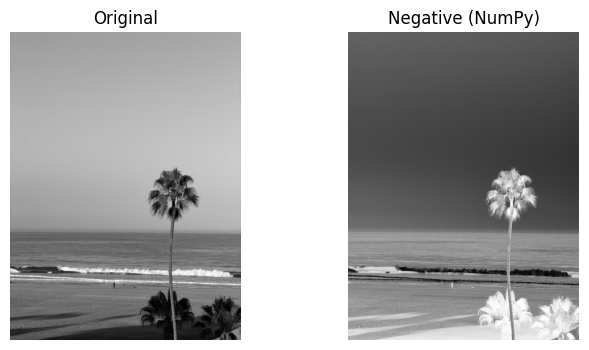

In [40]:
# ── 1. Negative ────────────────────────────────────
# Method 1: NumPy array manipulation
img_array = np.array(img)
negative_array = 255 - img_array
negative_img = Image.fromarray(negative_array.astype(np.uint8))

plt.figure(figsize=(8, 4))
plt.subplot(1, 2, 1), plt.imshow(img, cmap='gray'), plt.title('Original'), plt.axis('off')
plt.subplot(1, 2, 2), plt.imshow(negative_img, cmap='gray'), plt.title('Negative (NumPy)'), plt.axis('off')
plt.show()


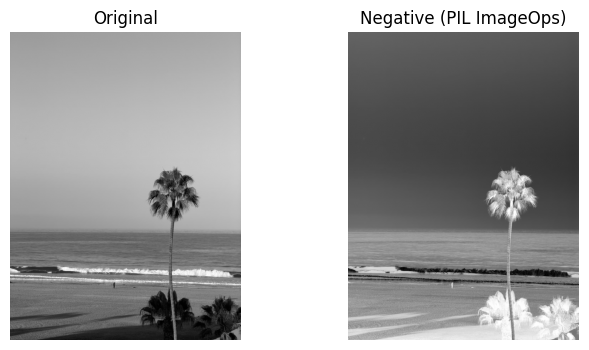

In [41]:
# Method 2: PIL's ImageOps
negative_img_pil = ImageOps.invert(img)

plt.figure(figsize=(8, 4))
plt.subplot(1, 2, 1), plt.imshow(img, cmap='gray'), plt.title('Original'), plt.axis('off')
plt.subplot(1, 2, 2), plt.imshow(negative_img_pil, cmap='gray'), plt.title('Negative (PIL ImageOps)'), plt.axis('off')
plt.show()


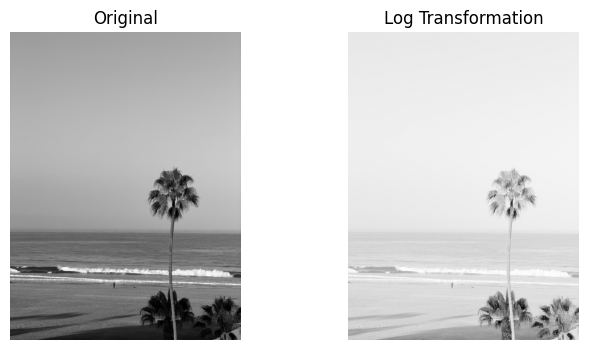

In [42]:
# ── 2. Log transformation ──────────────────────────

# s = c · log(1 + r) --> We need to find c.
# We want the maximum output value (s) to be 255 when the maximum input value (r) is 255:
# 255 = c · log(1 + 255)
# c = 255 / log(1 + 255)
c = 255 / np.log(1 + 255)

# Apply the log transformation to each pixel
img_array = np.array(img, dtype=np.float64)
log_array = c * np.log(1 + img_array)
log_img = Image.fromarray(log_array.astype(np.uint8))

plt.figure(figsize=(8, 4))
plt.subplot(1, 2, 1), plt.imshow(img, cmap='gray'), plt.title('Original'), plt.axis('off')
plt.subplot(1, 2, 2), plt.imshow(log_img, cmap='gray'), plt.title('Log Transformation'), plt.axis('off')
plt.show()


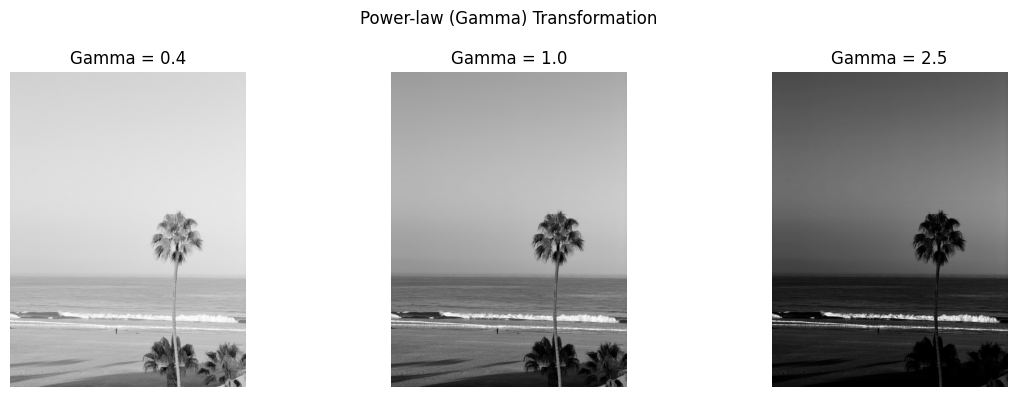

In [43]:
# ── 3. Power-law / Gamma correction ───────────────

img_array = np.array(img, dtype=np.float64)


normalized = img_array / 255.0

gamma_values = [0.4, 1.0, 2.5]

plt.figure(figsize=(12, 4))
for i, gamma in enumerate(gamma_values):
    gamma_corrected = np.power(normalized, gamma)
    gamma_img_array = (gamma_corrected * 255).astype(np.uint8)
    gamma_img = Image.fromarray(gamma_img_array)

    plt.subplot(1, len(gamma_values), i + 1)
    plt.imshow(gamma_img, cmap='gray')
    plt.title(f'Gamma = {gamma}')
    plt.axis('off')

plt.suptitle('Power-law (Gamma) Transformation')
plt.tight_layout()
plt.show()